In [208]:
# We are going to cut this data by share of inventors per parental income
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("table_1b.csv")
df = df[['par_stateabbrv', 'kid_count', 'inventor', 'inventor_pq_1', 'inventor_pq_2', 'inventor_pq_3', 'inventor_pq_4', 'inventor_pq_5',
         'top5cit_pq_1', 'top5cit_pq_2', 'top5cit_pq_3', 'top5cit_pq_4', 'top5cit_pq_5']]

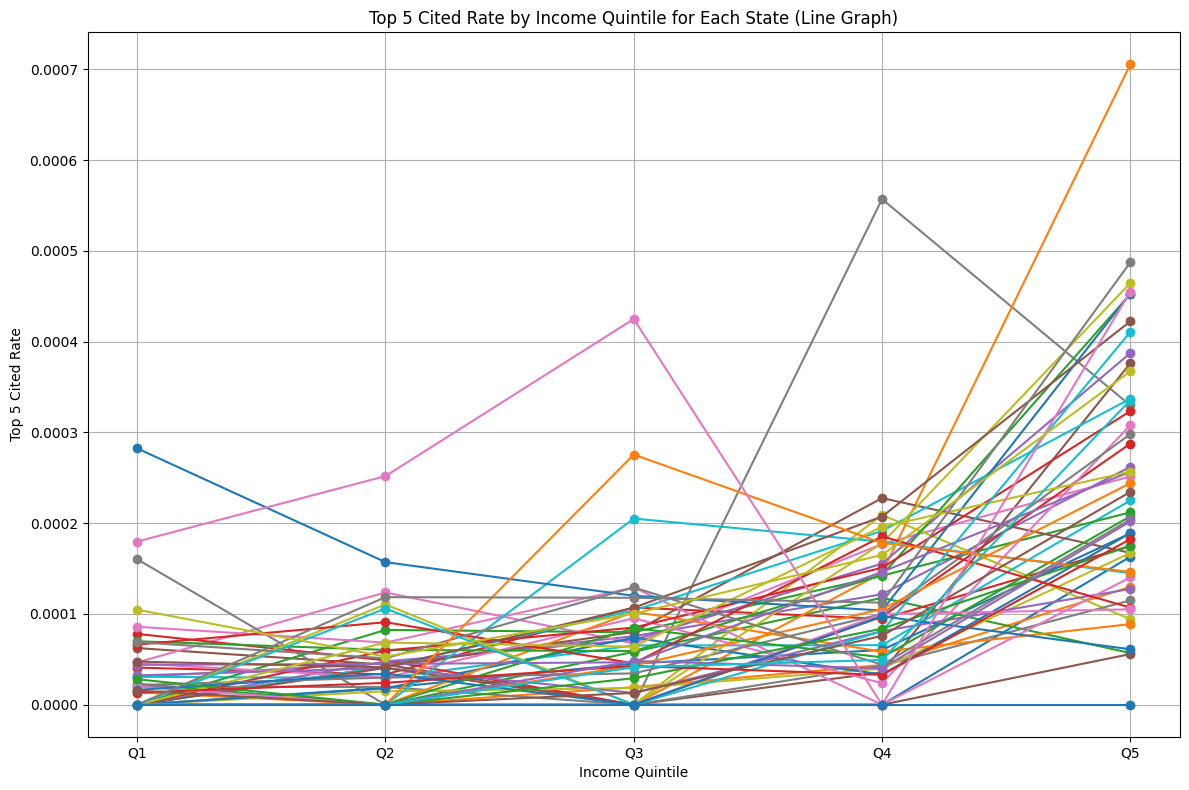

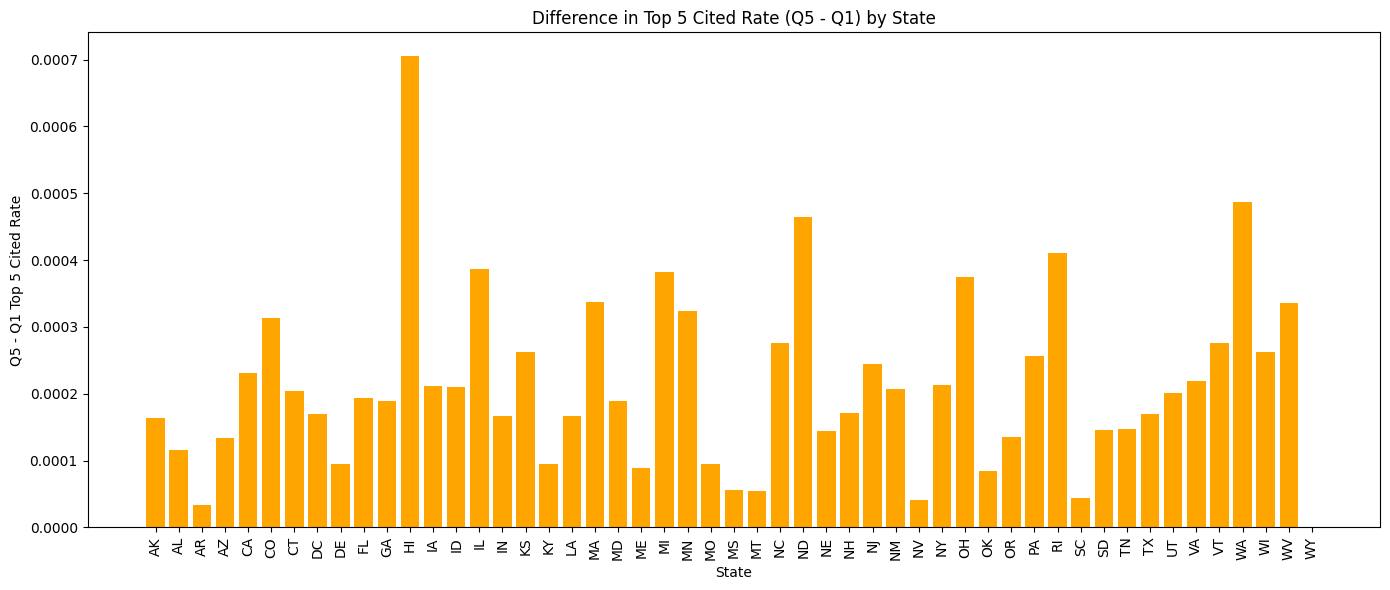

In [209]:
# Plot top5cit_pq by income quintile for each state (line graph)
top5cit_quintile_cols = ['top5cit_pq_1', 'top5cit_pq_2', 'top5cit_pq_3', 'top5cit_pq_4', 'top5cit_pq_5']

plt.figure(figsize=(12, 8))
for state in df['par_stateabbrv'].unique():
    state_data = df[df['par_stateabbrv'] == state][top5cit_quintile_cols].iloc[0]
    plt.plot(range(1, 6), state_data, marker='o', label=state)

plt.xlabel('Income Quintile')
plt.ylabel('Top 5 Cited Rate')
plt.title('Top 5 Cited Rate by Income Quintile for Each State (Line Graph)')
plt.xticks(range(1, 6), [f'Q{i}' for i in range(1, 6)])
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the difference between Q5 and Q1 top5cit_pq rates by state
q5_q1_diff_top5cit = df['top5cit_pq_5'] - df['top5cit_pq_1']
state_labels = df['par_stateabbrv']

plt.figure(figsize=(14, 6))
plt.bar(state_labels, q5_q1_diff_top5cit, color='orange')
plt.xlabel('State')
plt.ylabel('Q5 - Q1 Top 5 Cited Rate')
plt.title('Difference in Top 5 Cited Rate (Q5 - Q1) by State')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plot Q5-Q1 difference by state on a US map using Plotly for top5cit_pq
import plotly.express as px

map_df_top5cit = df.copy()
map_df_top5cit['q5_q1_diff_top5cit'] = map_df_top5cit['top5cit_pq_5'] - map_df_top5cit['top5cit_pq_1']

fig = px.choropleth(
    map_df_top5cit,
    locations='par_stateabbrv',
    locationmode='USA-states',
    color='q5_q1_diff_top5cit',
    scope='usa',
    color_continuous_scale='Oranges',
    labels={'q5_q1_diff_top5cit': 'Q5 - Q1 Top 5 Cited Rate'},
    title='Difference in Top 5 Cited Rate (Q5 - Q1) by State'
)
fig.update_layout(coloraxis_colorbar_tickformat='.4f')
fig.show()

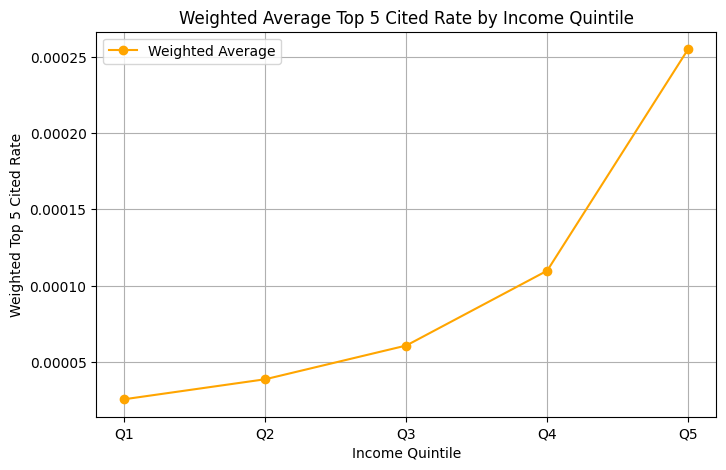

In [210]:
# Calculate weighted average top5cit_pq rate by income quintile using kid_count as weights
weighted_rates_top5cit = []
top5cit_quintile_cols = ['top5cit_pq_1', 'top5cit_pq_2', 'top5cit_pq_3', 'top5cit_pq_4', 'top5cit_pq_5']
for col in top5cit_quintile_cols:
    weighted_rate = (df[col] * df['kid_count']).sum() / df['kid_count'].sum()
    weighted_rates_top5cit.append(weighted_rate)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), weighted_rates_top5cit, marker='o', color='orange', label='Weighted Average')
plt.xlabel('Income Quintile')
plt.ylabel('Weighted Top 5 Cited Rate')
plt.title('Weighted Average Top 5 Cited Rate by Income Quintile')
plt.xticks(range(1, 6), [f'Q{i}' for i in range(1, 6)])
plt.grid(True)
plt.legend()
plt.show()

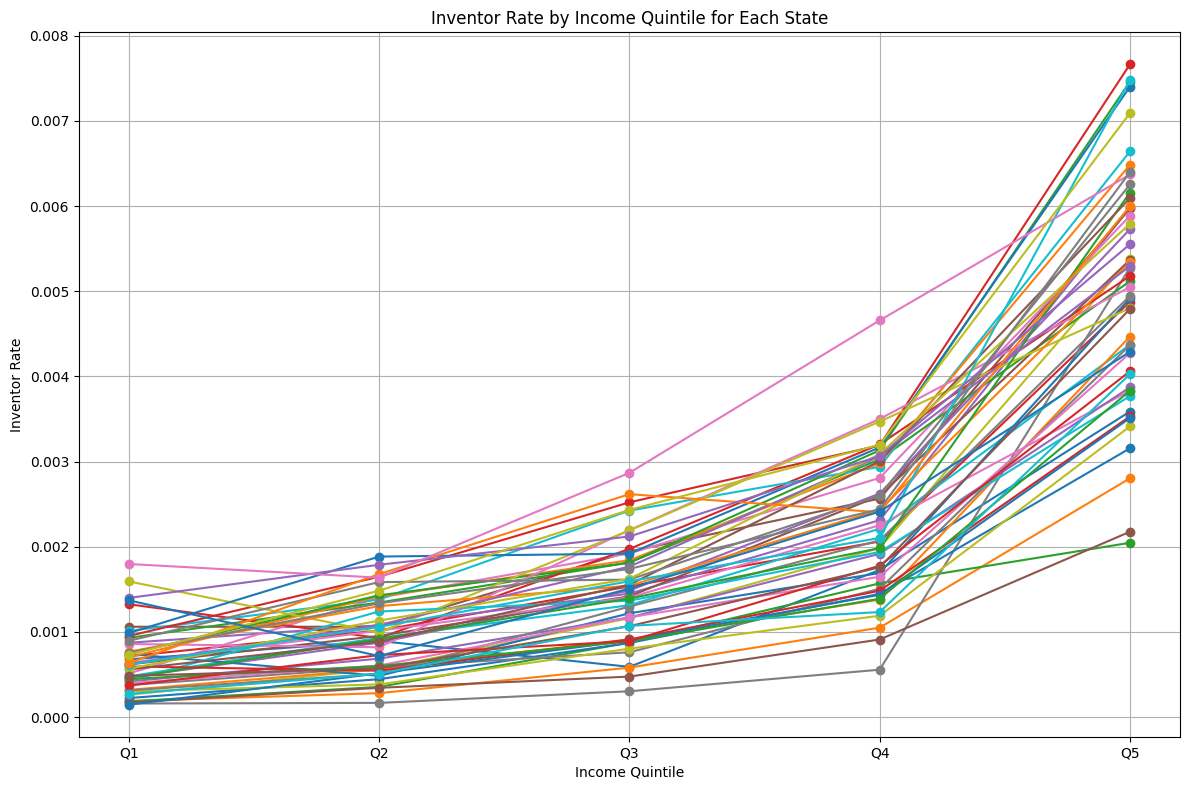

In [211]:

quintile_cols = ['inventor_pq_1', 'inventor_pq_2', 'inventor_pq_3', 'inventor_pq_4', 'inventor_pq_5']

plt.figure(figsize=(12, 8))
for state in df['par_stateabbrv'].unique():
    state_data = df[df['par_stateabbrv'] == state][quintile_cols].iloc[0]
    plt.plot(range(1, 6), state_data, marker='o', label=state)

plt.xlabel('Income Quintile')
plt.ylabel('Inventor Rate')
plt.title('Inventor Rate by Income Quintile for Each State')
plt.xticks(range(1, 6), [f'Q{i}' for i in range(1, 6)])
plt.grid(True)
plt.tight_layout()
plt.show()

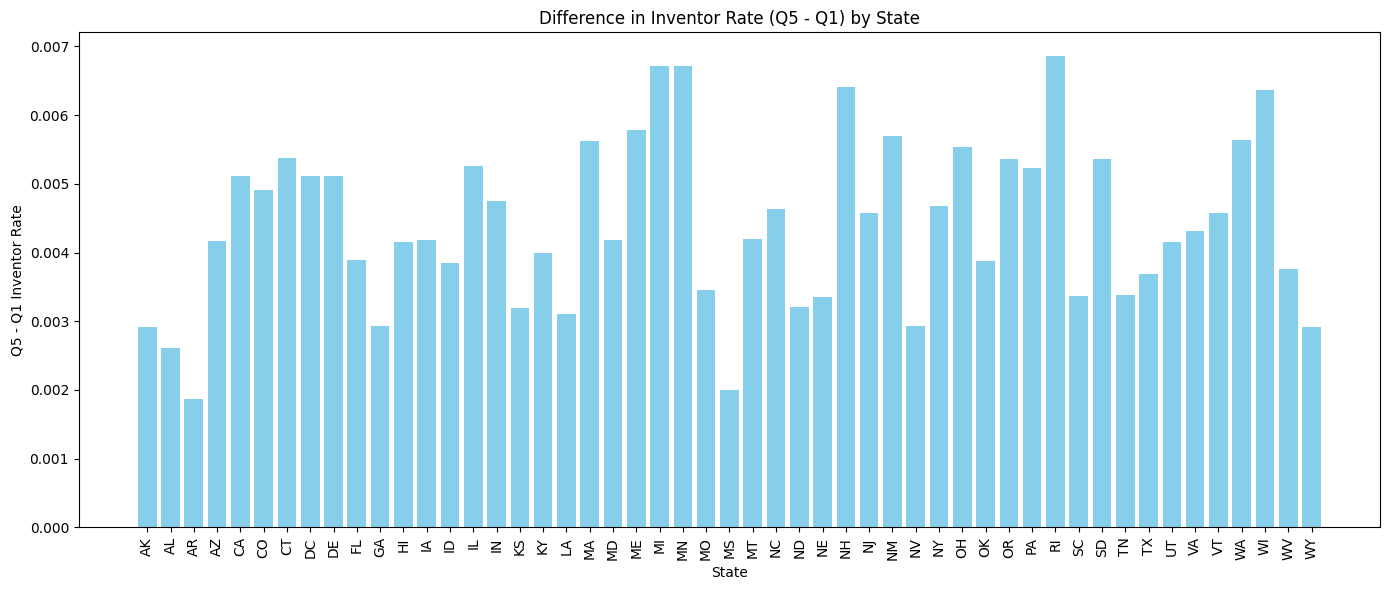

In [212]:
# Plot the difference between Q5 and Q1 inventor rates by state
q5_q1_diff = df['inventor_pq_5'] - df['inventor_pq_1']
state_labels = df['par_stateabbrv']

plt.figure(figsize=(14, 6))
plt.bar(state_labels, q5_q1_diff, color='skyblue')
plt.xlabel('State')
plt.ylabel('Q5 - Q1 Inventor Rate')
plt.title('Difference in Inventor Rate (Q5 - Q1) by State')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [213]:
# Plot Q5-Q1 difference by state on a US map using Plotly
import plotly.express as px

map_df = df.copy()
map_df['q5_q1_diff'] = map_df['inventor_pq_5'] - map_df['inventor_pq_1']

fig = px.choropleth(
    map_df,
    locations='par_stateabbrv',
    locationmode='USA-states',
    color='q5_q1_diff',
    scope='usa',
    color_continuous_scale='Viridis',
    labels={'q5_q1_diff': 'Q5 - Q1 Inventor Rate'},
    title='Difference in Inventor Rate (Q5 - Q1) by State'
)
fig.show()

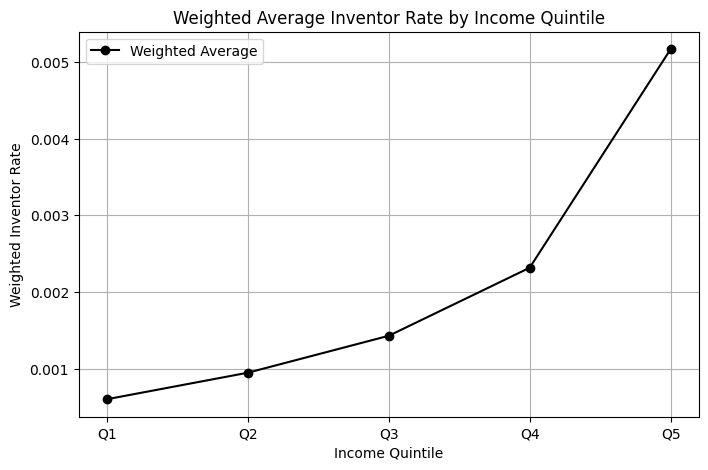

In [214]:
# Calculate weighted average inventor rate by income quintile using kid_count as weights
weighted_rates = []
quintile_cols = ['inventor_pq_1', 'inventor_pq_2', 'inventor_pq_3', 'inventor_pq_4', 'inventor_pq_5']
for col in quintile_cols:
    weighted_rate = (df[col] * df['kid_count']).sum() / df['kid_count'].sum()
    weighted_rates.append(weighted_rate)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), weighted_rates, marker='o', color='black', label='Weighted Average')
plt.xlabel('Income Quintile')
plt.ylabel('Weighted Inventor Rate')
plt.title('Weighted Average Inventor Rate by Income Quintile')
plt.xticks(range(1, 6), [f'Q{i}' for i in range(1, 6)])
plt.grid(True)
plt.legend()
plt.show()

In [215]:
# We are going to cut this data as inventor income over time (I think we can do year and age). 
df1 = pd.read_csv("table_4a.csv")
df1 = df1[['year', 'age', 'cohort', 'count', 'total_inc_p10', 'total_inc_p20', 'total_inc_p30', 'total_inc_p40', 'total_inc_p50', 'total_inc_p60', 'total_inc_p70', 'total_inc_p80', 'total_inc_p90', 'total_inc_p99', 'total_inc_mean']]
df1.dropna()
df1 = df1[df1['total_inc_mean'] >= 0]

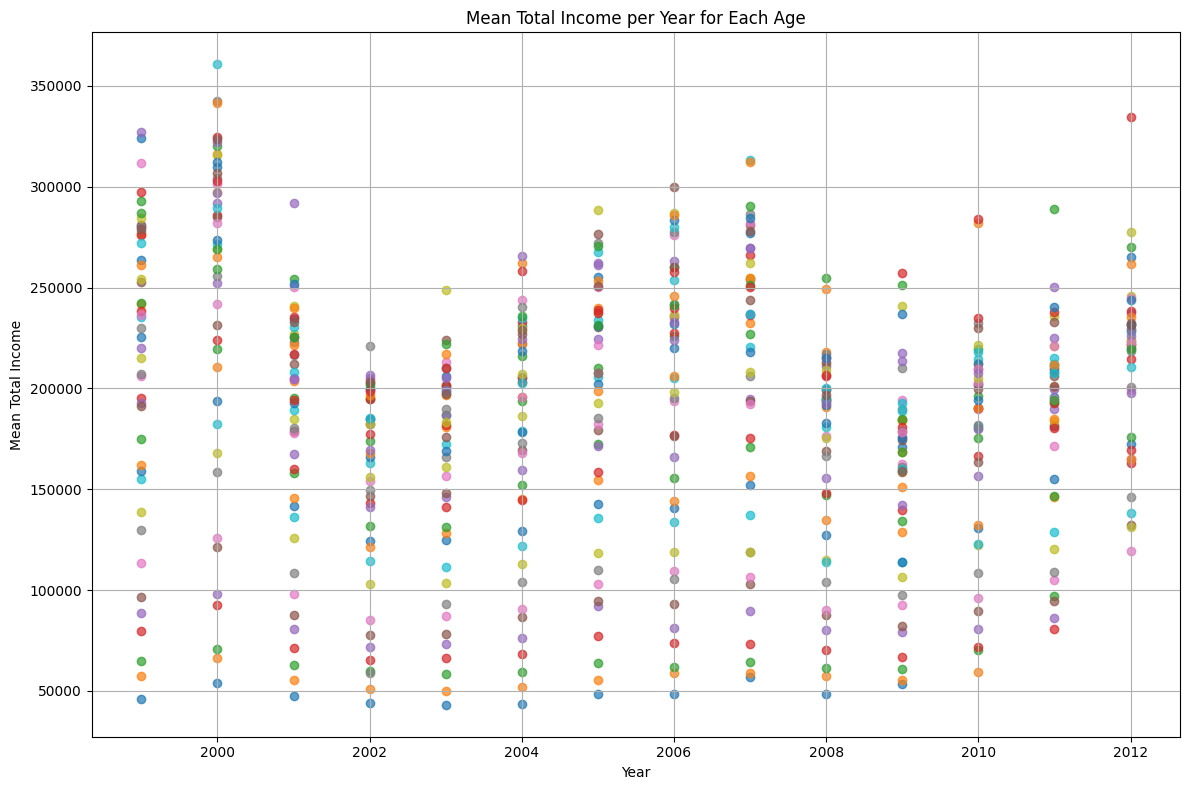

In [216]:
# Scatterplot of total_inc_mean per year for each age
groups = df1.groupby('age')
plt.figure(figsize=(12, 8))
for age, group in groups:
    plt.scatter(group['year'], group['total_inc_mean'], label=f'Age {age}', alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Mean Total Income')
plt.title('Mean Total Income per Year for Each Age')
# plt.legend(title='Age', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

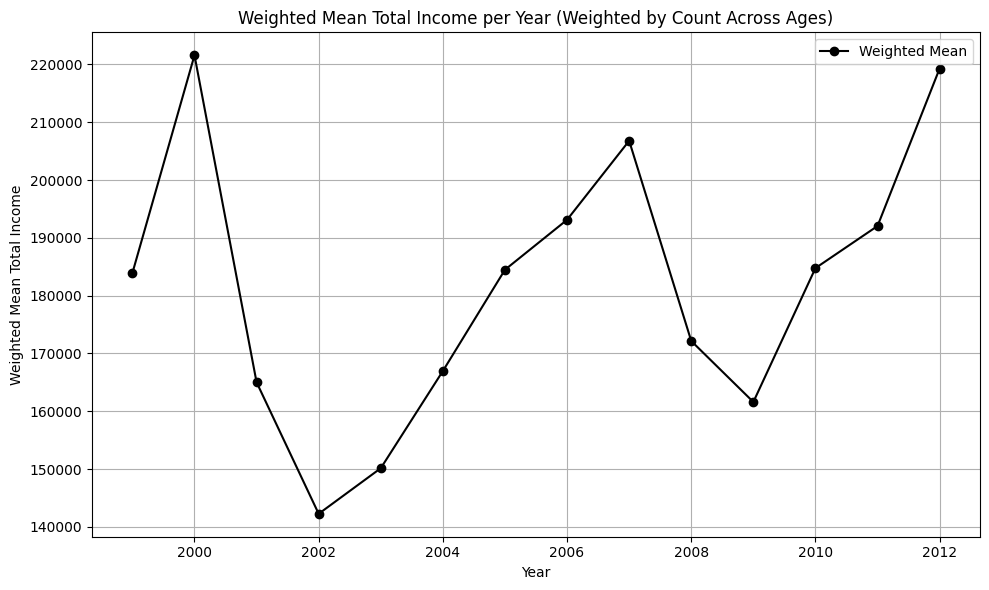

In [217]:
# Calculate weighted mean total income per year (across all ages, weighted by count)
weighted_mean_income = df1.groupby('year').apply(
    lambda g: (g['total_inc_mean'] * g['count']).sum() / g['count'].sum(), include_groups=False
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(
    weighted_mean_income.index,
    weighted_mean_income.values,
    marker='o',
    color='black',
    label='Weighted Mean'
)
plt.xlabel('Year')
plt.ylabel('Weighted Mean Total Income')
plt.title('Weighted Mean Total Income per Year (Weighted by Count Across Ages)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


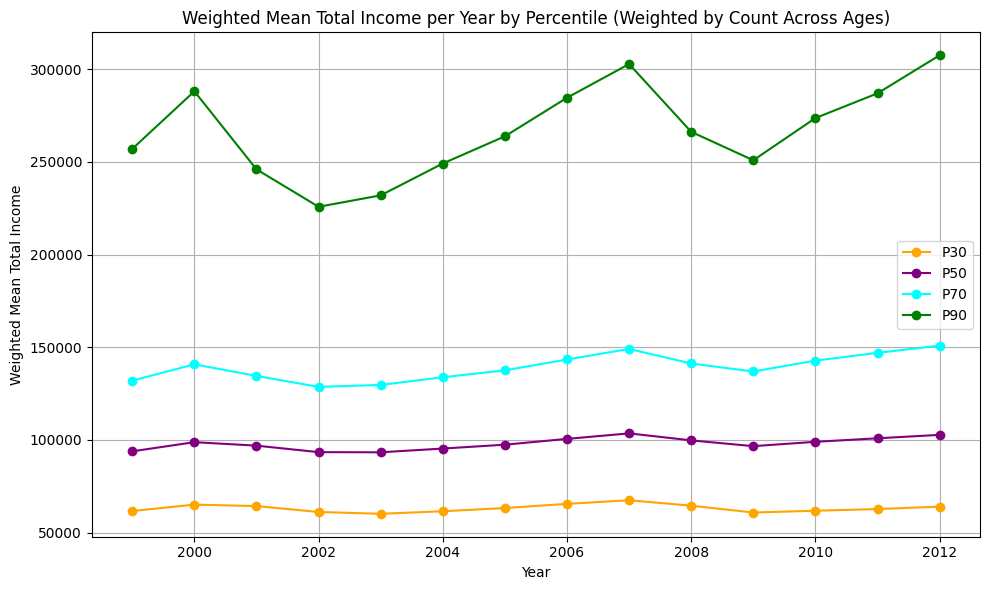

In [218]:
# Calculate weighted mean total income per year for percentiles 30, 50, 70, 90 (across all ages, weighted by count)
percentile_cols = ['total_inc_p30', 'total_inc_p50', 'total_inc_p70', 'total_inc_p90']
weighted_percentiles = {}
for col in percentile_cols:
    weighted_percentiles[col] = (
    df1[['year', col, 'count']]
    .groupby('year', group_keys=False)
    .apply(lambda g: (g[col] * g['count']).sum() / g['count'].sum(), include_groups=False)
)
plt.figure(figsize=(10, 6))
plt.plot(weighted_percentiles['total_inc_p30'].index, weighted_percentiles['total_inc_p30'].values, marker='o', color='orange', label='P30')
plt.plot(weighted_percentiles['total_inc_p50'].index, weighted_percentiles['total_inc_p50'].values, marker='o', color='purple', label='P50')
plt.plot(weighted_percentiles['total_inc_p70'].index, weighted_percentiles['total_inc_p70'].values, marker='o', color='cyan', label='P70')
plt.plot(weighted_percentiles['total_inc_p90'].index, weighted_percentiles['total_inc_p90'].values, marker='o', color='green', label='P90')
plt.xlabel('Year')
plt.ylabel('Weighted Mean Total Income')
plt.title('Weighted Mean Total Income per Year by Percentile (Weighted by Count Across Ages)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()